# Lead Scoring — RF & HGB Sweep × Concordance Thresholds

`composite = 2 × AUC_test + gap_pp` · Concordance ∈ {0.75, 0.80, 0.85, 0.90}


## 1 · Config & Imports


In [1]:
import re, json, os, sys, time, warnings, joblib
import numpy as np, pandas as pd
from itertools import product as iterproduct
from tqdm.auto import tqdm
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.tree import export_text
from sklearn.neighbors import BallTree
import matplotlib.pyplot as plt, matplotlib.patches as mpatches

sys.path.append(os.path.abspath(".."))
warnings.filterwarnings("ignore")


/Users/Rohanchoudhary/Desktop/projs/genie_stocks/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Run config ──
CONCORDANCE_THRESHOLDS = [0.75, 0.80, 0.85, 0.90]
N_RANDOM_SAMPLES       = 120
TEST_SIZE              = 0.30
RANDOM_STATE           = 42
FILL_VALUE             = -999
TARGET                 = "installed_decision"
RADIUS_M               = 100.0
K_MIN                  = 3
MODEL_DIR              = "../models/concordance_sweep"
os.makedirs(MODEL_DIR, exist_ok=True)


In [3]:
# ── Plot theme ──
plt.rcParams.update({
    "figure.facecolor": "#0a0e17", "axes.facecolor": "#111827",
    "axes.edgecolor": "#1e293b", "axes.labelcolor": "#9ca3af",
    "xtick.color": "#6b7280", "ytick.color": "#6b7280",
    "text.color": "#e2e8f0", "grid.color": "#1e293b",
    "font.family": "monospace", "font.size": 10,
})
AMBER, BLUE, GREEN  = "#f0b429", "#60a5fa", "#10b981"
RED, PURPLE, CYAN   = "#ef4444", "#a78bfa", "#22d3ee"
PINK, GRAY          = "#f472b6", "#4a5568"


## 2 · Data Load & Ops Merge


In [4]:
df_raw = pd.read_hdf("../reports/test_scored.h5", "df")
df_ops = pd.read_csv("../reports/partner_ops_train_vector.csv")
print(f"Scored: {df_raw.shape}  |  Ops: {df_ops.shape}")

# Detect temporal windows from ops columns
TEMPORAL_WINDOWS = sorted([
    int(c.replace("se_", "").replace("d", ""))
    for c in df_ops.columns if re.match(r"^se_\d+d$", c) and "delta" not in c
])
print(f"Temporal windows: {TEMPORAL_WINDOWS}")


Scored: (18082, 205)  |  Ops: (1475, 43)
Temporal windows: [30, 60, 365]


In [5]:
# Build ops column list
smallest_wd = min(TEMPORAL_WINDOWS)
rf_ops_cols = ["partner_id"]
for wd in TEMPORAL_WINDOWS:
    rf_ops_cols += [f"se_{wd}d", f"decline_rate_{wd}d", f"median_response_min_{wd}d"]
    if wd != smallest_wd:
        rf_ops_cols += [
            f"se_delta_{smallest_wd}_{wd}",
            f"decline_rate_delta_{smallest_wd}_{wd}",
            f"response_delta_{smallest_wd}_{wd}",
        ]
rf_ops_cols += [
    "queue_velocity", "plan_created_rate", "active_tickets",
    "nmbr_active_leads", "expected_daily_slots", "has_shock",
]
rf_ops_cols = [c for c in rf_ops_cols if c in df_ops.columns]


In [6]:
# Merge ops onto scored data
df_raw["partner_id"] = df_raw["partner_id"].astype(str)
df_ops["partner_id"] = df_ops["partner_id"].astype(str)
df_raw = df_raw.merge(df_ops[rf_ops_cols], on="partner_id", how="left", suffixes=("", "_ops"))
df_raw = df_raw.loc[:, ~df_raw.columns.str.endswith("_ops")]
_ops_feature_cols = [c for c in rf_ops_cols if c != "partner_id"]
print(f"After ops merge: {df_raw.shape}  |  Ops cols: {len(_ops_feature_cols)}")


After ops merge: (18082, 224)  |  Ops cols: 19


## 3 · Feature Definition


In [7]:
FEATURES_SPATIAL = [
    "predicted_field_hex", "predicted_field_hex_all_wmean",
    "predicted_field_hex_all_kswmean", "predicted_field_hex_all_min",
    "predicted_field_hex_all_max", "predicted_field_hex_all_std",
    "n_overlapping_hexes_field", "total_sources_all_hexes", "contested_field",
    "predicted_field_hex_30d", "predicted_field_hex_60d",
    "predicted_field_hex_365d", "field_momentum",
    # temporal source counts (step2 temporal scoring)
    "total_sources_field_30d", "total_sources_field_60d",
    "total_sources_field_365d",
]
FEATURES_HEX = [
    "parent_se", "parent_total", "parent_color_numeric",
    "n_covering_partners", "parent_overlap", "install_velocity",
    "weighted_se_30d_shrunk", "weighted_se_60d_shrunk",
    "weighted_se_365d_shrunk", "se_momentum",
]
FEATURES_HOP = [
    "hop1_se_wmean", "hop2_se_wmean", "hop3_se_wmean",
    "hop1_se_std", "hop2_se_std", "hop3_se_std",
    "hop1_count", "hop2_count", "hop3_count",
    "se_gradient_1to3", "se_confirmed", "isolation_ratio",
]


In [8]:
FEATURES_TEMPORAL_HOP = [
    f"hop{h}_se_{w}d_wmean" for h in [1,2,3] for w in [30,60,365]
] + [
    f"se_gradient_1to3_{w}d" for w in [30,60,365]
] + [
    f"se_confirmed_{w}d" for w in [30,60,365]
]
FEATURES_CONTESTED = [
    "contested_area_km2", "contested_radius_m", "contested_se",
    "contested_se_30d", "contested_se_60d", "contested_se_365d",
    "n_overlapping_partners",
]
FEATURES_BOUNDARY = [
    "dist_to_boundary_edge_point_hex", "dist_to_cluster_center_point_hex",
    "depth_score_point_hex", "mean_dist_to_edge_m", "mean_dist_to_center_m",
    "total_area_boundaries", "nmbr_overlap_clusters",
    "nearest_boundary_dist_m", "nmbr_boundaries_within_100m",
    "worst_depth_score", "any_near_edge", "is_solo_cluster",
]


In [9]:
FEATURES_GEOMETRY = [
    "local_anisotropy", "local_density", "hull_area",
    "linearity_score", "spread_m", "dense_score", "gully_score", "sparse_score",
] + [
    f"{m}_{w}d" for m in ["local_density","dense_score","sparse_score","spread_m"]
    for w in [30,60,365]
]
FEATURES_LEAD = ["hard_density", "density_regime"]


In [10]:
# ── Step2-derived features: active base, gravity, G1 ──
FEATURES_ACTIVE_BASE = [
    "ab_count_50m", "ab_count_100m", "ab_count_200m", "ab_count_500m",
    "ab_nearest_dist_m",
]
FEATURES_DERIVED = [
    "total", "parent_installs",
]


In [11]:
# ── Assemble all feature families (numeric only) ──
FEATURES = (
    FEATURES_SPATIAL + FEATURES_HEX + FEATURES_HOP
    + FEATURES_TEMPORAL_HOP + FEATURES_CONTESTED + FEATURES_BOUNDARY
    + FEATURES_GEOMETRY + FEATURES_LEAD
    + FEATURES_ACTIVE_BASE + FEATURES_DERIVED
    + _ops_feature_cols
)
_num_cols = set(df_raw.select_dtypes(include="number").columns)
available = [f for f in FEATURES if f in _num_cols]
missing   = [f for f in FEATURES if f not in df_raw.columns]
_skipped  = [f for f in FEATURES if f in df_raw.columns and f not in _num_cols]
print(f"Features: {len(available)}/{len(FEATURES)} available, "
      f"{len(missing)} missing, {len(_skipped)} skipped (non-numeric)")
if _skipped:
    print(f"  skipped: {_skipped}")


Features: 114/120 available, 5 missing, 1 skipped (non-numeric)
  skipped: ['parent_overlap']


In [12]:
# Family color map
_families = {
    "spatial": FEATURES_SPATIAL, "hex": FEATURES_HEX, "hop": FEATURES_HOP,
    "hop_temporal": FEATURES_TEMPORAL_HOP, "contested": FEATURES_CONTESTED,
    "boundary": FEATURES_BOUNDARY, "geometry": FEATURES_GEOMETRY,
    "lead": FEATURES_LEAD, "active_base": FEATURES_ACTIVE_BASE,
    "derived": FEATURES_DERIVED, "ops": _ops_feature_cols,
}
family_map = {f: fam for fam, feats in _families.items() for f in feats}
fam_colors = {
    "spatial": AMBER, "hex": BLUE, "hop": PURPLE, "hop_temporal": PURPLE,
    "contested": PINK, "boundary": CYAN, "geometry": GREEN,
    "lead": RED, "active_base": "#06b6d4", "derived": "#facc15",
    "ops": "#ff6b6b",
}


## 4 · Feature Correlation & Collinearity

Run **before** model training to catch redundancy, zero-variance duds, and collinear clusters.

In [13]:
# ── Build analysis frame on full scored data (no model dependency) ──
_feat_df = df_raw[available + [TARGET]].dropna(subset=[TARGET]).copy()
print(f"Analysis frame: {_feat_df.shape[0]:,} rows × {len(available)} features")

Analysis frame: 18,082 rows × 114 features


### 4a · Basic feature health

In [14]:
# Zero-variance & near-zero-variance
_nuniq = _feat_df[available].nunique()
_zero_var = _nuniq[_nuniq <= 1].index.tolist()
_near_zero = _nuniq[(_nuniq > 1) & (_nuniq <= 3)].index.tolist()
print(f"Zero-variance ({len(_zero_var)}):  {_zero_var}")
print(f"Near-zero-var ({len(_near_zero)}): {_near_zero}")

# Missing-value fraction
_miss = _feat_df[available].isnull().mean().sort_values(ascending=False)
_high_miss = _miss[_miss > 0.3]
if len(_high_miss):
    print(f">30% missing ({len(_high_miss)}):")
    for f, v in _high_miss.items():
        print(f"  {v:.1%}  {f}")
else:
    print("No feature has >30% missing.")

Zero-variance (1):  ['expected_daily_slots']
Near-zero-var (4): ['any_near_edge', 'is_solo_cluster', 'density_regime', 'has_shock']
>30% missing (11):
  100.0%  expected_daily_slots
  84.3%  nearest_boundary_dist_m
  84.3%  nmbr_boundaries_within_100m
  58.4%  spread_m_30d
  58.4%  local_density_30d
  58.4%  dense_score_30d
  58.4%  sparse_score_30d
  40.6%  sparse_score_60d
  40.6%  spread_m_60d
  40.6%  local_density_60d
  40.6%  dense_score_60d


### 4b · Pearson correlation with target

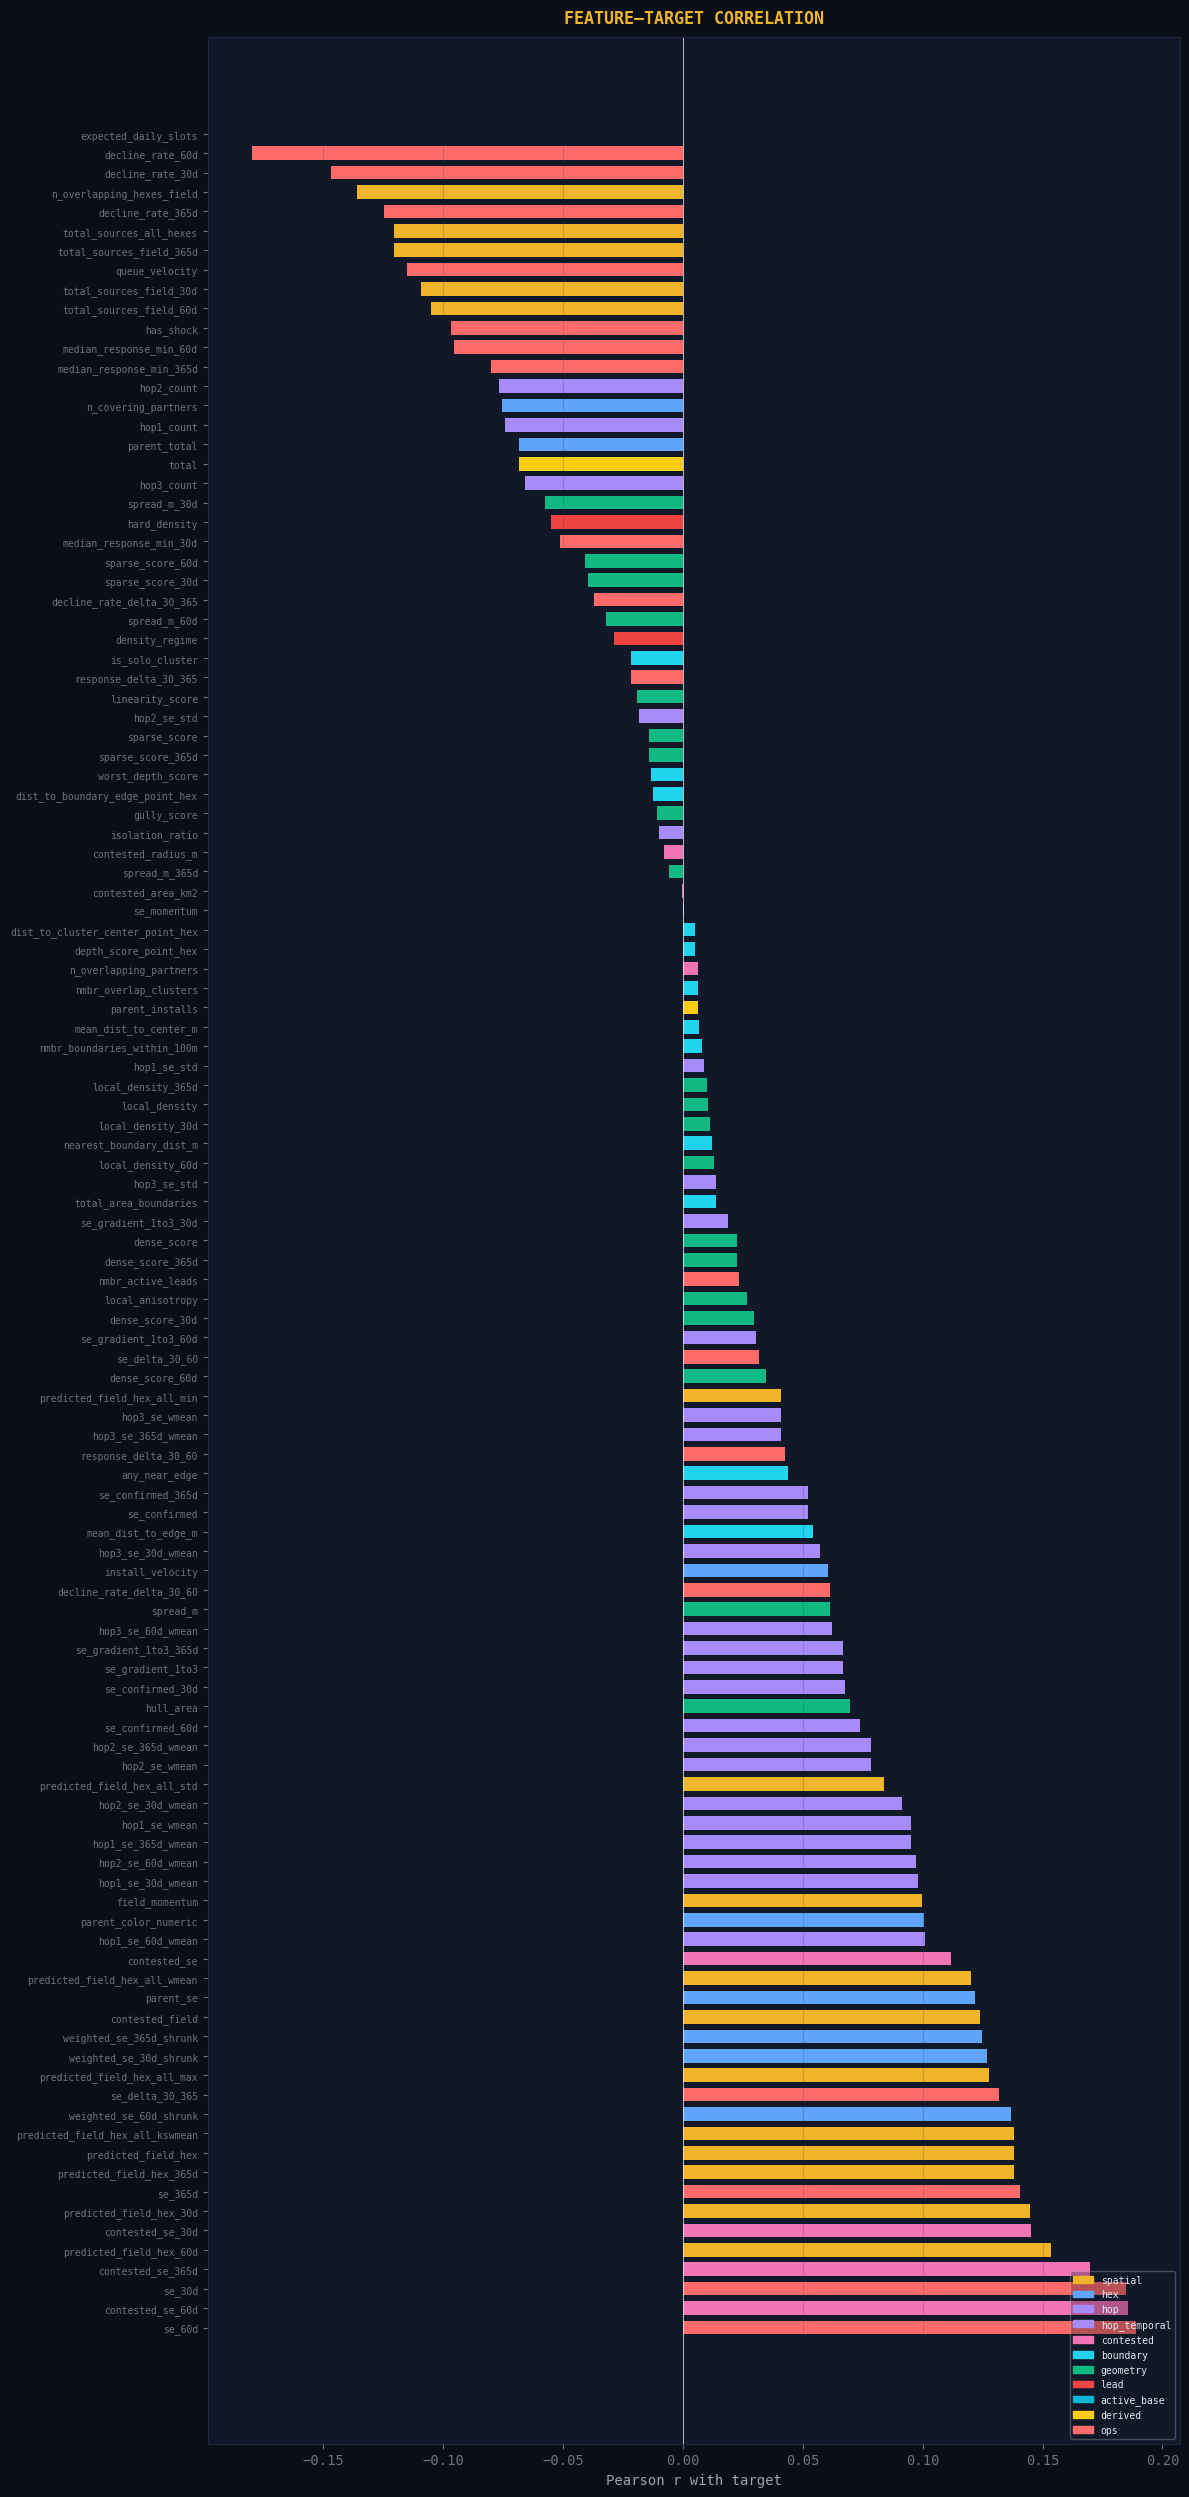

Top 15 positive:
  +0.1889  se_60d
  +0.1856  contested_se_60d
  +0.1848  se_30d
  +0.1698  contested_se_365d
  +0.1536  predicted_field_hex_60d
  +0.1454  contested_se_30d
  +0.1450  predicted_field_hex_30d
  +0.1408  se_365d
  +0.1381  predicted_field_hex_365d
  +0.1381  predicted_field_hex
  +0.1381  predicted_field_hex_all_kswmean
  +0.1367  weighted_se_60d_shrunk
  +0.1317  se_delta_30_365
  +0.1276  predicted_field_hex_all_max
  +0.1270  weighted_se_30d_shrunk
Top 15 negative:
  -0.0753  n_covering_partners
  -0.0767  hop2_count
  -0.0799  median_response_min_365d
  -0.0954  median_response_min_60d
  -0.0967  has_shock
  -0.1052  total_sources_field_60d
  -0.1092  total_sources_field_30d
  -0.1152  queue_velocity
  -0.1206  total_sources_field_365d
  -0.1206  total_sources_all_hexes
  -0.1244  decline_rate_365d
  -0.1357  n_overlapping_hexes_field
  -0.1468  decline_rate_30d
  -0.1797  decline_rate_60d
  +nan  expected_daily_slots


In [15]:
_corr_target = _feat_df[available].corrwith(_feat_df[TARGET]).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, max(6, len(available)*0.22)))
_colors_bar = [fam_colors.get(family_map.get(f, ""), GRAY) for f in _corr_target.index]
ax.barh(range(len(_corr_target)), _corr_target.values, color=_colors_bar, height=0.7)
ax.set_yticks(range(len(_corr_target)))
ax.set_yticklabels(_corr_target.index, fontsize=7)
ax.axvline(0, color="white", lw=0.5)
ax.set_xlabel("Pearson r with target")
ax.set_title("FEATURE–TARGET CORRELATION", fontsize=12, fontweight="bold", color=AMBER, pad=10)
ax.grid(axis="x", alpha=0.2)
patches = [mpatches.Patch(color=c, label=k) for k, c in fam_colors.items()]
ax.legend(handles=patches, loc="lower right", fontsize=7, framealpha=0.3)
plt.tight_layout(); plt.show()

# Print top & bottom
print("Top 15 positive:")
for f, v in _corr_target.head(15).items(): print(f"  {v:+.4f}  {f}")
print("Top 15 negative:")
for f, v in _corr_target.tail(15).items(): print(f"  {v:+.4f}  {f}")

### 4c · Inter-feature correlation heatmap (family-level)

Features with any |r|>0.5 pair: 102 / 114


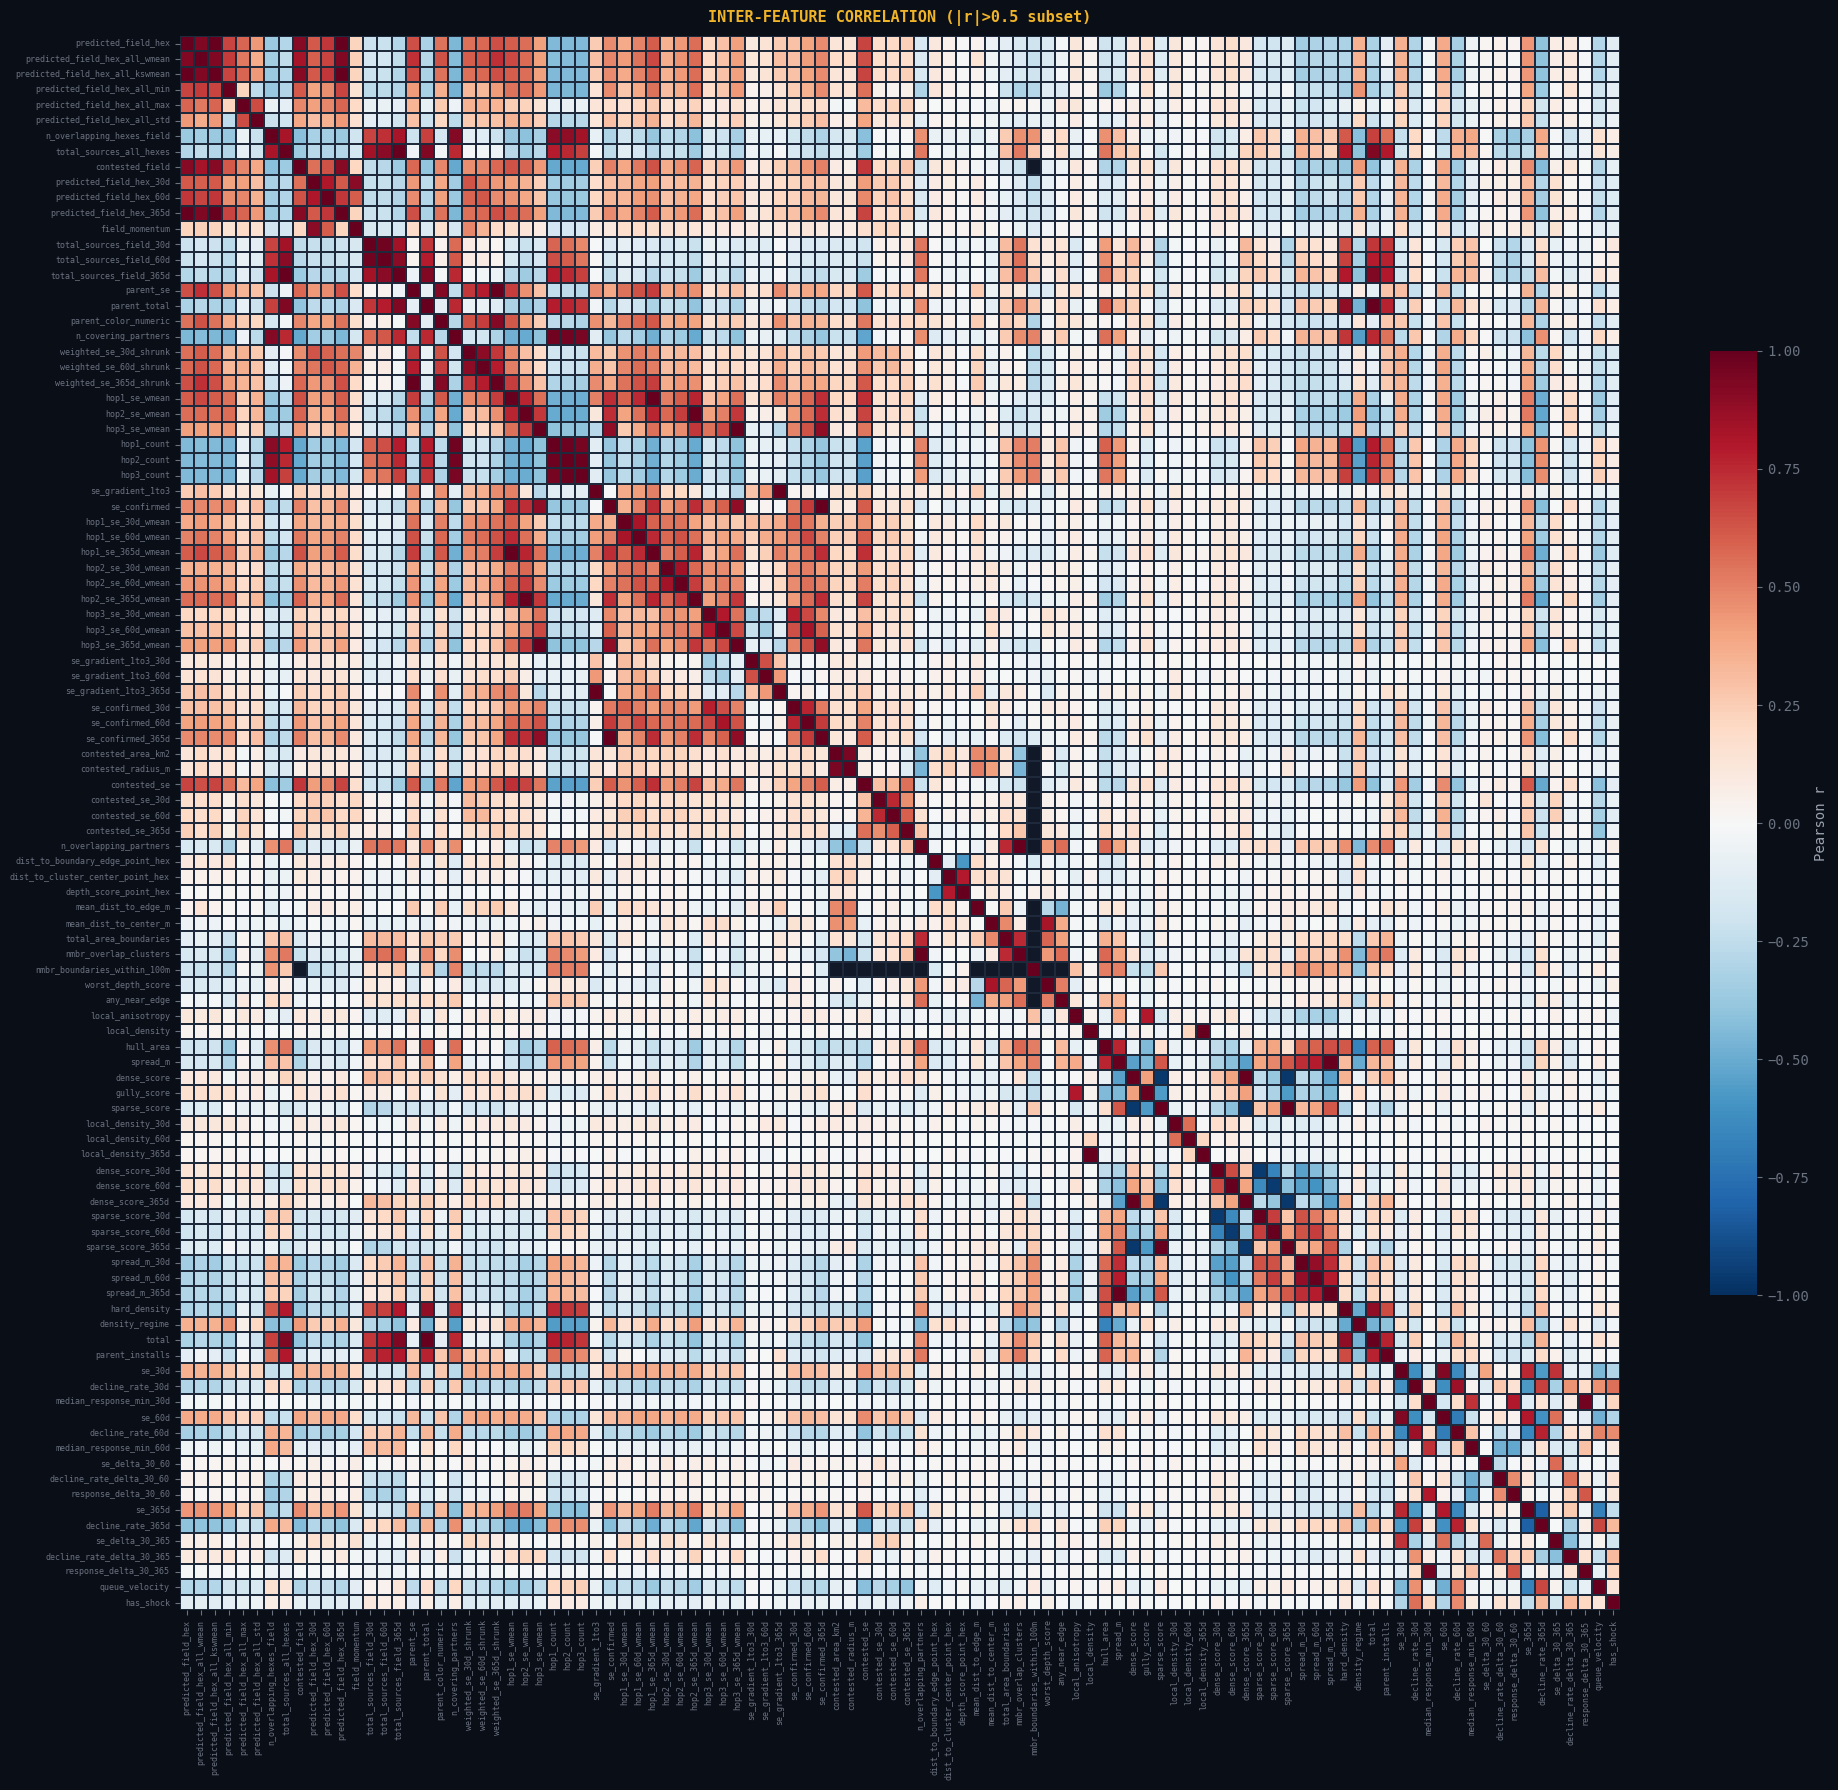

In [16]:
import seaborn as sns

# Cluster-sorted heatmap of |r| > 0.5 features only
_corr_mx = _feat_df[available].corr()

# Flag features that have at least one |r| > 0.5 partner (excl self)
_has_high = (_corr_mx.abs() > 0.5).sum() > 1  # >1 because diagonal
_hot_feats = _has_high[_has_high].index.tolist()
print(f"Features with any |r|>0.5 pair: {len(_hot_feats)} / {len(available)}")

if len(_hot_feats) > 2:
    _sub = _corr_mx.loc[_hot_feats, _hot_feats]
    fig, ax = plt.subplots(figsize=(min(20, len(_hot_feats)*0.35+2),
                                     min(18, len(_hot_feats)*0.35+2)))
    sns.heatmap(_sub, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                linewidths=0.1, linecolor="#1e293b",
                xticklabels=True, yticklabels=True, ax=ax,
                cbar_kws={"shrink": 0.6, "label": "Pearson r"})
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=6, rotation=90)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
    ax.set_title("INTER-FEATURE CORRELATION (|r|>0.5 subset)", fontsize=11,
                 fontweight="bold", color=AMBER, pad=10)
    plt.tight_layout(); plt.show()

### 4d · High-collinearity pairs (|r| > 0.7)

In [17]:
_high_corr_pairs = []
for i in range(len(available)):
    for j in range(i+1, len(available)):
        r = _corr_mx.iloc[i, j]
        if abs(r) > 0.7:
            _high_corr_pairs.append((available[i], available[j], round(r, 3)))
_high_corr_pairs.sort(key=lambda x: -abs(x[2]))

print(f"Highly correlated pairs (|r|>0.7): {len(_high_corr_pairs)}")
for a, b, r in _high_corr_pairs[:30]:
    fa = family_map.get(a, "?")
    fb = family_map.get(b, "?")
    same = "✓" if fa == fb else "✗"
    print(f"  {r:+.3f}  {a:45s} ({fa}) ↔ {b} ({fb})  same_fam={same}")

Highly correlated pairs (|r|>0.7): 151
  +1.000  predicted_field_hex                           (spatial) ↔ predicted_field_hex_all_kswmean (spatial)  same_fam=✓
  +1.000  predicted_field_hex                           (spatial) ↔ predicted_field_hex_365d (spatial)  same_fam=✓
  +1.000  predicted_field_hex_all_kswmean               (spatial) ↔ predicted_field_hex_365d (spatial)  same_fam=✓
  +1.000  total_sources_all_hexes                       (spatial) ↔ total_sources_field_365d (spatial)  same_fam=✓
  +1.000  parent_se                                     (hex) ↔ weighted_se_365d_shrunk (hex)  same_fam=✓
  +1.000  parent_total                                  (hex) ↔ total (derived)  same_fam=✗
  +1.000  hop1_se_wmean                                 (hop) ↔ hop1_se_365d_wmean (hop_temporal)  same_fam=✗
  +1.000  hop2_se_wmean                                 (hop) ↔ hop2_se_365d_wmean (hop_temporal)  same_fam=✗
  +1.000  hop3_se_wmean                                 (hop) ↔ hop3_se_365d

### 4e · Collinear clusters (connected components at |r| > 0.85)

In [18]:
# Build adjacency at |r|>0.85 and find connected components
import networkx as nx

G = nx.Graph()
G.add_nodes_from(available)
for a, b, r in _high_corr_pairs:
    if abs(r) > 0.85:
        G.add_edge(a, b, weight=r)

_clusters = [c for c in nx.connected_components(G) if len(c) > 1]
_clusters.sort(key=len, reverse=True)
print(f"Collinear clusters (|r|>0.85): {len(_clusters)}")
for ci, clust in enumerate(_clusters):
    clust = sorted(clust, key=lambda f: abs(_corr_target.get(f, 0)), reverse=True)
    print(f"Cluster {ci+1} ({len(clust)} features) — keep candidate: {clust[0]}")
    for f in clust:
        print(f"    r_target={_corr_target.get(f,0):+.4f}  {f}  [{family_map.get(f,'')}]")

Collinear clusters (|r|>0.85): 21
Cluster 1 (7 features) — keep candidate: total_sources_field_365d
    r_target=-0.1206  total_sources_field_365d  [spatial]
    r_target=-0.1206  total_sources_all_hexes  [spatial]
    r_target=-0.1092  total_sources_field_30d  [spatial]
    r_target=-0.1052  total_sources_field_60d  [spatial]
    r_target=-0.0683  total  [derived]
    r_target=-0.0683  parent_total  [hex]
    r_target=-0.0549  hard_density  [lead]
Cluster 2 (5 features) — keep candidate: predicted_field_hex_365d
    r_target=+0.1381  predicted_field_hex_365d  [spatial]
    r_target=+0.1381  predicted_field_hex_all_kswmean  [spatial]
    r_target=+0.1381  predicted_field_hex  [spatial]
    r_target=+0.1240  contested_field  [spatial]
    r_target=+0.1203  predicted_field_hex_all_wmean  [spatial]
Cluster 3 (5 features) — keep candidate: n_overlapping_hexes_field
    r_target=-0.1357  n_overlapping_hexes_field  [spatial]
    r_target=-0.0767  hop2_count  [hop]
    r_target=-0.0753  n_cov

### 4f · Summary: candidates to drop

Review the collinear clusters above. Within each cluster, the feature with highest |r_target| is the keep candidate; the rest are drop candidates. No auto-drop — flag for manual review.

In [19]:
_drop_candidates = []
for clust in _clusters:
    ranked = sorted(clust, key=lambda f: abs(_corr_target.get(f, 0)), reverse=True)
    _drop_candidates.extend(ranked[1:])  # everything except best-correlated-with-target
print(f"Drop candidates from collinear clusters: {len(_drop_candidates)}")
for f in _drop_candidates:
    print(f"  {f:45s}  r_target={_corr_target.get(f,0):+.4f}  [{family_map.get(f,'')}]")

# Store for optional use downstream
COLLINEAR_DROP_CANDIDATES = set(_drop_candidates)

Drop candidates from collinear clusters: 37
  total_sources_all_hexes                        r_target=-0.1206  [spatial]
  total_sources_field_30d                        r_target=-0.1092  [spatial]
  total_sources_field_60d                        r_target=-0.1052  [spatial]
  total                                          r_target=-0.0683  [derived]
  parent_total                                   r_target=-0.0683  [hex]
  hard_density                                   r_target=-0.0549  [lead]
  predicted_field_hex_all_kswmean                r_target=+0.1381  [spatial]
  predicted_field_hex                            r_target=+0.1381  [spatial]
  contested_field                                r_target=+0.1240  [spatial]
  predicted_field_hex_all_wmean                  r_target=+0.1203  [spatial]
  hop2_count                                     r_target=-0.0767  [hop]
  n_covering_partners                            r_target=-0.0753  [hex]
  hop1_count                                   

## 5 · Concordance-Gated Label Cleaning

In [20]:
from data_lib.data_fetch.get_data import get_test_data
import data_lib.config as config

df_test_raw = get_test_data(config.TEST_START_DATE, config.TEST_END_DATE)
mobile_decisions = df_test_raw.groupby("mobile")["final_decision"].first()
hard_mobiles = mobile_decisions[mobile_decisions.isin(["INSTALLED","DECLINED"])].index
ambig_mobiles = mobile_decisions[mobile_decisions.isin(["INDETERMINATE","HANGING"])].index
print(f"Hard: {len(hard_mobiles)}  |  Ambiguous: {len(ambig_mobiles)}")


Fetching TEST data (2025-10-20 to 2025-11-09)...
[WiomData] snowflake_select_start: select partner_id, mobile, first_notified_time,
               case when lco_account_installed = par
Standardization Cutoff (p40): 288.63 minutes
STANDARDISED DECISIONS (TRAIN):
final_decision
DECLINED         12334
INSTALLED        10477
INDETERMINATE     5635
HANGING           2697
Name: count, dtype: int64
Hard: 13268  |  Ambiguous: 4304


In [21]:
# Build BallTree on hard training decisions
df_train_h5 = pd.read_hdf("../artifacts/train_data.h5", "df")
hard_train = df_train_h5[df_train_h5["final_decision"].isin(["INSTALLED","DECLINED"])].copy()
hard_train["is_install"] = (hard_train["final_decision"] == "INSTALLED").astype(int)

train_rad = np.radians(hard_train[["latitude","longitude"]].values)
train_labels = hard_train["is_install"].values
ball_tree = BallTree(train_rad, metric="haversine")

# Query ambiguous leads once — reuse for all thresholds
ambig_in_df = df_raw[df_raw["mobile"].isin(ambig_mobiles)].copy()
radius_rad = RADIUS_M / 6_371_000
ambig_rad = np.radians(ambig_in_df[["latitude","longitude"]].values)
idx_list, _ = ball_tree.query_radius(ambig_rad, r=radius_rad, return_distance=True)
print(f"Ambiguous in scored_df: {len(ambig_in_df)}")


Ambiguous in scored_df: 4304


In [22]:
def filter_by_concordance(conc_thresh):
    """Return filtered df for a given concordance threshold."""
    keep_mask = []
    for idxs in idx_list:
        if len(idxs) < K_MIN:
            keep_mask.append(False)
            continue
        frac_pos = train_labels[idxs].mean()
        keep_mask.append(max(frac_pos, 1 - frac_pos) >= conc_thresh)
    keep_mask = np.array(keep_mask)
    concordant = ambig_in_df.loc[keep_mask, "mobile"].values
    keep = set(hard_mobiles) | set(concordant)
    df_filt = df_raw[df_raw["mobile"].isin(keep)].copy()
    n_ambig = len(concordant)
    return df_filt, n_ambig


## 6 · Evaluation Utilities

`composite = 2 × AUC_test + gap_pp`

In [23]:
def eval_model(model, X_tr, y_tr, X_te, y_te):
    """Fit metrics + decile SE. composite = 200*auc_test + gap_pp."""
    p_train = model.predict(X_tr)
    p_test  = model.predict(X_te)
    auc_train = roc_auc_score(y_tr, p_train)
    auc_test  = roc_auc_score(y_te, p_test)

    edf = pd.DataFrame({"y": y_te.values, "p": p_test})
    edf["decile"] = pd.qcut(
        edf["p"].rank(method="first"), q=10, labels=False
    ) + 1
    tbl = edf.groupby("decile").agg(n=("y","count"), inst=("y","sum"))
    tbl["se"] = tbl["inst"] / tbl["n"]

    d1_se  = tbl.loc[1, "se"]
    d10_se = tbl.loc[10, "se"]
    gap_pp = (d10_se - d1_se) * 100
    mono   = bool((tbl["se"].diff().dropna() >= 0).all())
    composite = 200 * auc_test + gap_pp

    result = dict(
        auc_train=round(auc_train,4), auc_test=round(auc_test,4),
        gap_pp=round(gap_pp,2), d1_se=round(d1_se,4),
        d10_se=round(d10_se,4), mono=mono,
        composite=round(composite,2),
    )
    for i in range(1, 11):
        result[f"d{i}_se"] = round(tbl.loc[i, "se"], 4)
        result[f"d{i}_n"]  = int(tbl.loc[i, "n"])
    return result


## 7 · Hyperparameter Grids

In [24]:
RF_GRID = {
    "n_estimators":     [200, 300, 500],
    "max_depth":        [6, 8, 12, 16, None],
    "min_samples_leaf": [20, 50, 100, 200],
    "max_features":     ["sqrt", 0.3, 0.5],
}
HGB_GRID = {
    "learning_rate":     [0.02, 0.04, 0.07, 0.10],
    "max_depth":         [3, 4, 6, 8],
    "min_samples_leaf":  [30, 50, 100, 200],
    "l2_regularization": [0.5, 2.0, 5.0, 10.0],
    "max_leaf_nodes":    [15, 31, 63],
}
HGB_FIXED = dict(
    loss="squared_error", max_iter=1000, max_bins=255,
    early_stopping=True, validation_fraction=0.15,
    n_iter_no_change=30, random_state=RANDOM_STATE,
)


In [25]:
# Pre-sample combos (same seed → reproducible across concordance thresholds)
np.random.seed(RANDOM_STATE)
all_rf  = list(iterproduct(*RF_GRID.values()))
all_hgb = list(iterproduct(*HGB_GRID.values()))
rf_idx  = np.random.choice(len(all_rf),  min(N_RANDOM_SAMPLES, len(all_rf)),  replace=False)
hgb_idx = np.random.choice(len(all_hgb), min(N_RANDOM_SAMPLES, len(all_hgb)), replace=False)
sampled_rf  = [all_rf[i]  for i in rf_idx]
sampled_hgb = [all_hgb[i] for i in hgb_idx]
print(f"RF: {len(all_rf)} → {len(sampled_rf)}  |  HGB: {len(all_hgb)} → {len(sampled_hgb)}")


RF: 180 → 120  |  HGB: 768 → 120


## 8 · Sweep Runner

In [26]:
def run_rf_sweep(X_tr, y_tr, X_te, y_te):
    """Run RF sweep, return (results_list, best_model)."""
    rows, best_comp, best_mdl = [], -np.inf, None
    for n_est, md, msl, mf in tqdm(sampled_rf, desc="RF"):
        m = RandomForestRegressor(
            n_estimators=n_est, max_depth=md, min_samples_leaf=msl,
            max_features=mf, random_state=RANDOM_STATE, n_jobs=-1)
        m.fit(X_tr, y_tr)
        ev = eval_model(m, X_tr, y_tr, X_te, y_te)
        row = {"model":"RF", "params": json.dumps(
            {"n_estimators":n_est,"max_depth":md,"min_samples_leaf":msl,"max_features":mf}),
            **{k:ev[k] for k in ev if k!="decile_tbl"}}
        rows.append(row)
        if ev["composite"] > best_comp:
            best_comp, best_mdl = ev["composite"], m
            print(f"  RF new best: auc={ev['auc_test']:.4f} gap={ev['gap_pp']:.2f} comp={ev['composite']:.2f}")

    return rows, best_mdl


In [27]:
def run_hgb_sweep(X_tr, y_tr, X_te, y_te):
    """Run HGB sweep, return (results_list, best_model)."""
    rows, best_comp, best_mdl = [], -np.inf, None
    for lr, md, msl, l2, mln in tqdm(sampled_hgb, desc="HGB"):
        m = HistGradientBoostingRegressor(
            learning_rate=lr, max_depth=md, min_samples_leaf=msl,
            l2_regularization=l2, max_leaf_nodes=mln, **HGB_FIXED)
        m.fit(X_tr, y_tr)
        ev = eval_model(m, X_tr, y_tr, X_te, y_te)
        row = {"model":"HGB", "params": json.dumps(
            {"learning_rate":lr,"max_depth":md,"min_samples_leaf":msl,
             "l2":l2,"max_leaf_nodes":mln,"n_iter":m.n_iter_}),
            **{k:ev[k] for k in ev if k!="decile_tbl"}}
        rows.append(row)
        if ev["composite"] > best_comp:
            best_comp, best_mdl = ev["composite"], m
            print(f"  HGB new best: auc={ev['auc_test']:.4f} gap={ev['gap_pp']:.2f} comp={ev['composite']:.2f}")
    return rows, best_mdl


## 9 · Concordance Sweep Loop

In [42]:
for conc in CONCORDANCE_THRESHOLDS:
    print(f"\n{'='*70}")
    print(f"  CONCORDANCE = {conc}")
    print(f"{'='*70}")

    # ── split on FULL data first ──
    X_all = df_raw[available].fillna(FILL_VALUE)
    y_all = df_raw[TARGET]
    mask = y_all.notna()
    X_all, y_all = X_all[mask], y_all[mask]

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_all, y_all, test_size=TEST_SIZE,
        random_state=RANDOM_STATE, stratify=y_all.astype(int))

    # ── concordance filter ONLY train ──
    df_c, n_ambig = filter_by_concordance(conc)
    conc_idx = df_c.index.intersection(X_tr.index)
    X_tr, y_tr = X_tr.loc[conc_idx], y_tr.loc[conc_idx]

    print(f"  train={len(X_tr)} (filtered)  test={len(X_te)} (full)  ambig_added={n_ambig}")

    # ── sweeps (unchanged) ──
    rf_rows, best_rf = run_rf_sweep(X_tr, y_tr, X_te, y_te)
    
    all_results = []
    for r in rf_rows: r["concordance"] = conc
    all_results.extend(rf_rows)

    hgb_rows, best_hgb = run_hgb_sweep(X_tr, y_tr, X_te, y_te)
    for r in hgb_rows: r["concordance"] = conc
    all_results.extend(hgb_rows)
    saved_models = {}
    for tag, mdl in [("RF", best_rf), ("HGB", best_hgb)]:
        path = f"{MODEL_DIR}/{tag}_conc{conc:.2f}.joblib"
        joblib.dump(mdl, path)
        saved_models[(conc, tag)] = path
        print(f"  saved {path}")


  CONCORDANCE = 0.75
  train=10889 (filtered)  test=5425 (full)  ambig_added=1751


RF:   1%|          | 1/120 [00:01<03:42,  1.87s/it]

  RF new best: auc=0.6751 gap=55.25 comp=190.28


RF:   2%|▏         | 2/120 [00:02<02:11,  1.11s/it]

  RF new best: auc=0.6756 gap=56.35 comp=191.48


...

  HGB new best: auc=0.6833 gap=61.33 comp=197.98


HGB:  60%|██████    | 72/120 [00:52<01:01,  1.28s/it]

  HGB new best: auc=0.6878 gap=60.59 comp=198.15


HGB: 100%|██████████| 120/120 [01:23<00:00,  1.44it/s]

  saved ../models/concordance_sweep/RF_conc0.90.joblib
  saved ../models/concordance_sweep/HGB_conc0.90.joblib


## 10 · Combined Leaderboard

In [43]:
df_train_h5.shape

(721722, 18)

In [44]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("composite", ascending=False).reset_index(drop=True)

metric_cols = ["concordance","model","params","auc_train","auc_test",
               "gap_pp","d1_se","d10_se","mono","composite"]
decile_cols = [f"d{d}_se" for d in range(1,11)] + [f"d{d}_n" for d in range(1,11)]
report_cols = [c for c in metric_cols + decile_cols if c in results_df.columns]

results_df[report_cols].to_csv("../reports/concordance_sweep_report.csv", index=False)
print(f"Saved {len(results_df)} rows to concordance_sweep_report.csv")


Saved 240 rows to concordance_sweep_report.csv


In [45]:
# Top 10 per concordance threshold
for conc in CONCORDANCE_THRESHOLDS:
    sub = results_df[results_df["concordance"]==conc].head(10)
    print(f"\n── C={conc} top 10 ──")
    print(sub[["model","auc_test","gap_pp","composite","mono","params"]].to_string(index=False))



── C=0.75 top 10 ──
Empty DataFrame
Columns: [model, auc_test, gap_pp, composite, mono, params]
Index: []

── C=0.8 top 10 ──
Empty DataFrame
Columns: [model, auc_test, gap_pp, composite, mono, params]
Index: []

── C=0.85 top 10 ──
Empty DataFrame
Columns: [model, auc_test, gap_pp, composite, mono, params]
Index: []

── C=0.9 top 10 ──
model  auc_test  gap_pp  composite  mono                                                                                                           params
   RF    0.6874   60.96     198.43  True                            {"n_estimators": 300, "max_depth": null, "min_samples_leaf": 20, "max_features": 0.3}
  HGB    0.6878   60.59     198.15  True {"learning_rate": 0.02, "max_depth": 6, "min_samples_leaf": 30, "l2": 10.0, "max_leaf_nodes": 63, "n_iter": 436}
  HGB    0.6867   60.77     198.11  True  {"learning_rate": 0.04, "max_depth": 6, "min_samples_leaf": 30, "l2": 0.5, "max_leaf_nodes": 63, "n_iter": 226}
   RF    0.6872   60.59     198.04 False    

## 11 · Concordance Comparison

In [46]:
summary = (results_df.groupby(["concordance","model"])
    .agg(best_composite=("composite","max"), best_auc=("auc_test","max"),
         best_gap=("gap_pp","max"), median_composite=("composite","median"),
         n_mono=("mono","sum"), n_runs=("mono","count"))
    .reset_index())
summary["mono_pct"] = (summary["n_mono"] / summary["n_runs"] * 100).round(1)
print(summary.to_string(index=False))


 concordance model  best_composite  best_auc  best_gap  median_composite  n_mono  n_runs  mono_pct
         0.9   HGB          198.15    0.6878     61.51           193.675      42     120      35.0
         0.9    RF          198.43    0.6877     60.96           191.995      48     120      40.0


## 12 · Best-Model Deep Dive

In [47]:
# Pick overall best concordance + model
best_row = results_df.iloc[0]
best_conc = best_row["concordance"]
best_type = best_row["model"]
best_path = saved_models[(best_conc, best_type)]
best_model = joblib.load(best_path)
print(f"Best: {best_type} @ concordance={best_conc}  composite={best_row['composite']}")
print(f"  AUC={best_row['auc_test']}  gap_pp={best_row['gap_pp']}  mono={best_row['mono']}")
print(f"  params: {best_row['params']}")


Best: RF @ concordance=0.9  composite=198.43
  AUC=0.6874  gap_pp=60.96  mono=True
  params: {"n_estimators": 300, "max_depth": null, "min_samples_leaf": 20, "max_features": 0.3}


In [48]:
# Rebuild test set for best concordance
df_best, _ = filter_by_concordance(best_conc)
X_b = df_best[available].fillna(FILL_VALUE)
y_b = df_best[TARGET]
mask = y_b.notna()
X_b, y_b = X_b[mask], y_b[mask]
_, X_te_b, _, y_te_b = train_test_split(
    X_b, y_b, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y_b.astype(int))
p_best = best_model.predict(X_te_b)


In [49]:
feat_df = df_best[available + [TARGET]].dropna(subset=[TARGET])
corr_target = feat_df.corr()[TARGET].drop(TARGET).sort_values(ascending=False)
print("Top 15 correlated with target:")
for feat, val in corr_target.head(15).items():
    print(f"  {val:+.4f}  {feat}")


Top 15 correlated with target:
  +0.2887  se_60d
  +0.2841  se_30d
  +0.2560  predicted_field_hex_60d
  +0.2453  se_365d
  +0.2373  predicted_field_hex_30d
  +0.2282  contested_se_60d
  +0.2245  predicted_field_hex_365d
  +0.2245  predicted_field_hex
  +0.2245  predicted_field_hex_all_kswmean
  +0.2080  contested_field
  +0.2055  contested_se_365d
  +0.2019  weighted_se_60d_shrunk
  +0.1998  predicted_field_hex_all_wmean
  +0.1947  contested_se
  +0.1895  hop1_se_365d_wmean


### 12a · Decile & ROC Curves

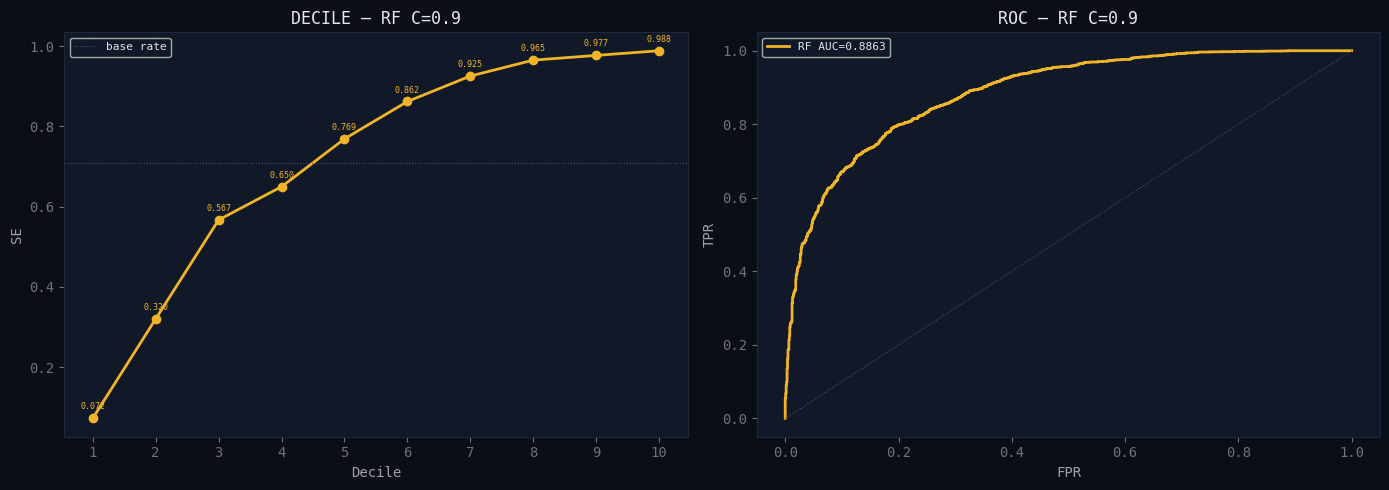

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decile curve
ax = axes[0]
edf = pd.DataFrame({"y": y_te_b.values, "p": p_best})
edf["d"] = pd.qcut(edf["p"], q=10, labels=False, duplicates="drop") + 1
tbl = edf.groupby("d").agg(n=("y","count"), inst=("y","sum"))
tbl["se"] = tbl["inst"] / tbl["n"]
d_range = list(range(1, len(tbl)+1))
ax.plot(d_range, tbl["se"].values, "o-", color=AMBER, lw=2, ms=6)
for j, se in enumerate(tbl["se"].values):
    ax.annotate(f"{se:.3f}", (j+1, se), fontsize=6, ha="center",
                va="bottom", xytext=(0,5), textcoords="offset points", color=AMBER)
ax.axhline(y_te_b.mean(), color=GRAY, ls=":", lw=0.8, label="base rate")
ax.set(xlabel="Decile", ylabel="SE", title=f"DECILE — {best_type} C={best_conc}")
ax.set_xticks(range(1,11)); ax.legend(fontsize=8); ax.grid(alpha=0.2)
# ROC curve
ax = axes[1]
fpr, tpr, _ = roc_curve(y_te_b, p_best)
roc_auc_val = auc(fpr, tpr)
ax.plot(fpr, tpr, color=AMBER, lw=2, label=f"{best_type} AUC={roc_auc_val:.4f}")
ax.plot([0,1],[0,1],":", color=GRAY, lw=0.8)
ax.set(xlabel="FPR", ylabel="TPR", title=f"ROC — {best_type} C={best_conc}")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()



### 12b · Feature Importance

In [52]:
# If best model is RF, plot feature importance directly; else load best RF
if best_type == "RF":
    imp_model = best_model
else:
    rf_path = saved_models[(best_conc, "RF")]
    imp_model = joblib.load(rf_path)

imp = pd.Series(imp_model.feature_importances_, index=available).sort_values(ascending=True)
colors = [fam_colors.get(family_map.get(f,""), GRAY) for f in imp.index]


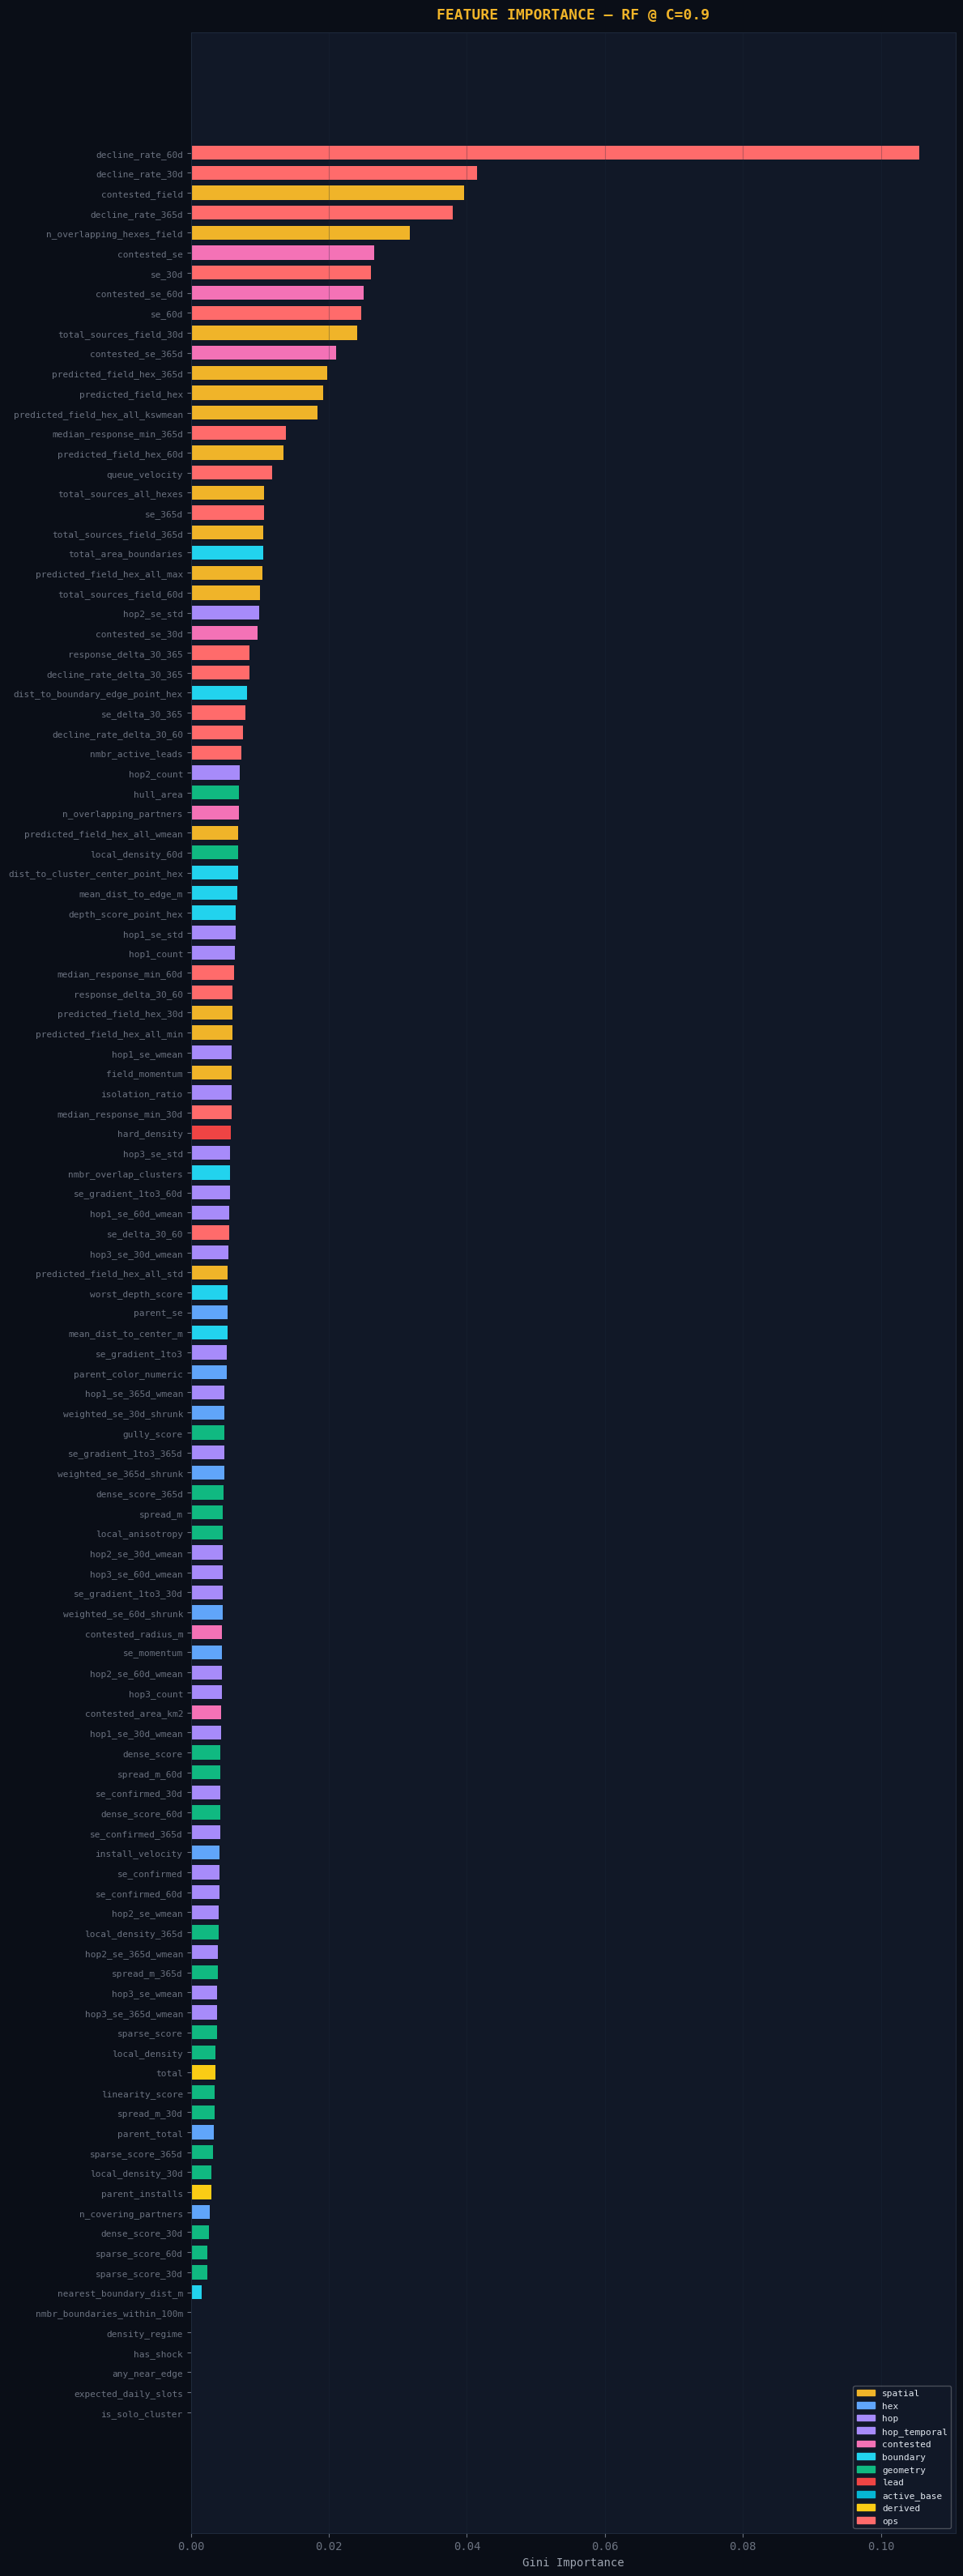

In [53]:
fig, ax = plt.subplots(figsize=(12, max(10, len(imp)*0.28)))
ax.barh(range(len(imp)), imp.values, color=colors, height=0.7, edgecolor="none")
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp.index, fontsize=8)
ax.set_xlabel("Gini Importance")
ax.set_title(f"FEATURE IMPORTANCE — RF @ C={best_conc}", fontsize=13,
             fontweight="bold", color=AMBER, pad=12)
ax.grid(axis="x", alpha=0.3)
patches = [mpatches.Patch(color=c, label=k) for k,c in fam_colors.items()]
ax.legend(handles=patches, loc="lower right", fontsize=8, framealpha=0.3)
plt.tight_layout(); plt.show()


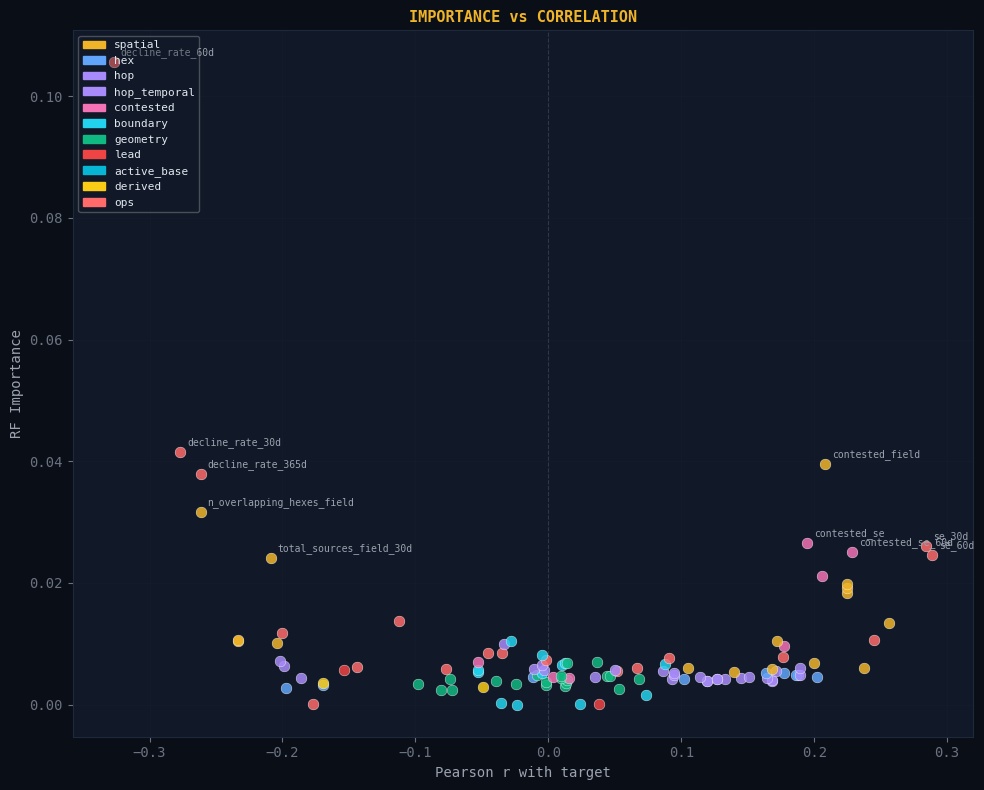

In [54]:
fig, ax = plt.subplots(figsize=(10, 8))
for feat in imp.index:
    c = fam_colors.get(family_map.get(feat,""), GRAY)
    ax.scatter(corr_target.get(feat,0), imp[feat],
               c=c, s=60, alpha=0.85, edgecolor="white", lw=0.3, zorder=3)
for feat in imp.nlargest(10).index:
    if feat in corr_target.index:
        ax.annotate(feat, (corr_target[feat], imp[feat]),
                    fontsize=7, color="#9ca3af", ha="left",
                    xytext=(5,5), textcoords="offset points")
ax.axvline(0, color=GRAY, ls="--", lw=0.8, alpha=0.5)
ax.set(xlabel="Pearson r with target", ylabel="RF Importance")
ax.set_title("IMPORTANCE vs CORRELATION", fontsize=11, fontweight="bold", color=AMBER)
ax.grid(alpha=0.2)
patches = [mpatches.Patch(color=c, label=k) for k,c in fam_colors.items()]
ax.legend(handles=patches, loc="upper left", fontsize=8, framealpha=0.3)
plt.tight_layout(); plt.show()


## 13 · Saved Models

In [55]:
print(f"{'Concordance':>12}  {'Model':>5}  {'Path'}")
print("-" * 60)
for (conc, tag), path in sorted(saved_models.items()):
    print(f"{conc:>12.2f}  {tag:>5}  {path}")
print(f"\nTotal models saved: {len(saved_models)}")


 Concordance  Model  Path
------------------------------------------------------------
        0.90    HGB  ../models/concordance_sweep/HGB_conc0.90.joblib
        0.90     RF  ../models/concordance_sweep/RF_conc0.90.joblib

Total models saved: 2
